In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py

import tensorflow as tf
tf.config.experimental.set_memory_growth(tf.config.list_physical_devices(device_type="GPU")[0], True)

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from tqdm import tqdm

from msfm.grid_pipeline import GridPipeline
from msfm.fiducial_pipeline import FiducialPipeline
from msfm.utils import logger, input_output, files, scales, power_spectra, parameters

from deep_lss.nets.custom_layers import MeanBinningLayer
from deep_lss.models.grid_model import GridLossModel
from deep_lss.utils import optimization

from msi.utils import preprocessing

In [3]:
bin_edges = power_spectra.get_cl_bins(30, 1500, 33)
print(bin_edges)
print(len(bin_edges))

[  30.           42.46307239   57.08578528   73.86813865   92.81013252
  113.91176687  137.17304172  162.59395706  190.17451288  219.9147092
  251.81454601  285.87402331  322.0931411   360.47189939  401.01029816
  443.70833742  488.56601718  535.58333742  584.76029816  636.09689939
  689.5931411   745.24902331  803.06454601  863.0397092   925.17451288
  989.46895706 1055.92304172 1124.53676687 1195.31013252 1268.24313865
 1343.33578528 1420.58807239 1500.        ]
33


In [4]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")

base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

with_lensing = True
with_clustering = False
params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# params = ["Om", "s8"]

# tfrecord pipeline

In [5]:
# conf = "/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias_debug.yaml"
# conf = files.load_config(conf)

# with_lensing = True
# with_clustering = False
# # params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# params = ["Om", "s8"]

# batch_size = 1024

In [6]:
# tfr_pattern = "/pscratch/sd/a/athomsen/v11desy3/v10/debug/linear_bias/tfrecords/grid/DESy3_grid_dmb_0000.tfrecord"

# grid_pipe = GridPipeline(
#     conf=conf,
#     params=params,
#     with_lensing=with_lensing,
#     with_clustering=with_clustering,
#     return_maps=False,
# )

# # TODO optimize
# grid_dset = grid_pipe.get_dset(
#     tfr_pattern=tfr_pattern,
#     local_batch_size=batch_size,
#     n_readers=1,
#     n_prefetch=0,
#     is_eval=False
# )

In [7]:
# %%time
# n_batches = 100
# for x in tqdm(grid_dset.take(n_batches), total=n_batches):
#     pass

In [8]:
# n_params = len(params)
# layers = 4
# hidden_units = 256

# n_cls = 1536
# n_channels = 10

# # inputs = tf.keras.Input(shape=cl_batch.shape[1:])
# inputs = tf.keras.Input(shape=(n_cls, n_channels))
# x = MeanBinningLayer(bin_edges=list(bin_edges))(inputs)
# x = tf.keras.layers.Flatten()(x)
# x = tf.keras.layers.LayerNormalization()(x)
# for i in range(layers):
#     x = tf.keras.layers.Dense(hidden_units, activation="relu")(x)
# outputs = tf.keras.layers.Dense(n_params)(x)
# network = tf.keras.Model(inputs=inputs, outputs=outputs, name="cl_model")

In [9]:
# optimizer  = tf.keras.optimizers.Adam(learning_rate=1e-5)

# model = GridLossModel(
#     network,
#     n_side=None,
#     indices=None,
#     input_shape=(None, n_cls, n_channels),
#     optimizer=optimizer,
# )

# model.setup_grid_loss_step(
#     batch_size,
#     n_channels,
#     n_params,
#     loss="mse",
#     clip_by_global_norm=10.0,
# )

In [10]:
# n_steps = 100
# losses = []
# for _, cl_batch, cosmo_batch, index_batch in tqdm(grid_dset.take(n_steps), total=n_steps):
#     loss = model.grid_train_step(cl_batch, cosmo_batch)
#     losses.append(loss)
    
# plt.plot(losses)

# h5 files

In [11]:
summary = "cls"

l_mins = 8 * [30]
def angle_to_ell(angles):
    return list(scales.angle_to_ell(np.array(angles), arcmin=True))
l_maxs = angle_to_ell([22.1, 15.1, 11.2, 9.4] + [65.1, 44.5, 34.1, 28.5])
n_bins = 33

apply_log = False
standardize = True
pca_components = None

fidu_summs, grid_summs, grid_cosmos, grid_i_sobols, file_dict, scaler, pca = preprocessing.get_reshaped_human_summaries(
    base_dir, 
    summary, 
    # file
    file_label=None,
    # configuration
    conf=conf, 
    params=params,
    concat_example_dim=False,
    do_plot=False,
    # selection
    with_lensing=with_lensing,
    with_clustering=with_clustering,
    with_cross_z=True,
    with_cross_probe=(with_lensing and with_clustering),
    # power spectra: scales
    l_mins=l_mins,
    l_maxs=l_maxs,
    n_bins=n_bins,
    # additional preprocessing
    apply_log=apply_log,
    standardize=standardize,
    pca_components=pca_components,
)

n_data_vector = grid_summs.shape[-1]
# out_dir = os.path.join(out_dir, summary) if (os.path.basename(out_dir) != summary) else out_dir
# os.makedirs(out_dir, exist_ok=True)

24-08-19 09:12:56 preprocessin INF   Applying scale cuts to the raw Cls 
24-08-19 09:12:56 preprocessin INF   l_mins = [30, 30, 30, 30, 30, 30, 30, 30] 
24-08-19 09:12:56 preprocessin INF   l_maxs = [488.6877828054298, 715.2317880794702, 964.2857142857142, 1148.936170212766, 165.89861751152074, 242.69662921348313, 316.7155425219941, 378.94736842105266] 
24-08-19 09:12:57 input_output INF   Array shapes: 
24-08-19 09:12:57 input_output INF   fiducial/i_example = (40000,) 
24-08-19 09:12:57 input_output INF   fiducial/i_noise   = (40000,) 
24-08-19 09:12:57 input_output INF   fiducial/cls/binned = (40000, 32, 36) 
24-08-19 09:12:57 input_output INF   fiducial/cls/bin_edges = (33, 36) 
24-08-19 09:12:57 input_output INF   grid/cosmo         = (2500, 240, 12) 
24-08-19 09:12:57 input_output INF   grid/i_example     = (2500, 240) 
24-08-19 09:12:57 input_output INF   grid/i_noise       = (2500, 240) 
24-08-19 09:12:57 input_output INF   grid/i_sobol       = (2500, 240) 
24-08-19 09:12:57 in

In [12]:
# train_test_split = 0.8
# i_split = int(0.8 * grid_summs.shape[1])

# grid_summs_train = grid_summs[:,:i_split,:] 
# grid_summs_test = grid_summs[:,i_split:,:]

# grid_cosmos_train = grid_cosmos[:,:i_split,:]
# grid_cosmos_test = grid_cosmos[:,i_split:,:]

# grid_summs_train = np.concatenate([grid_summs_train[i, ...] for i in range(grid_summs_train.shape[0])], axis=0)
# grid_summs_test = np.concatenate([grid_summs_test[i, ...] for i in range(grid_summs_test.shape[0])], axis=0)

# grid_cosmos_train = np.concatenate([grid_cosmos_train[i, ...] for i in range(grid_cosmos_train.shape[0])], axis=0)
# grid_cosmos_test = np.concatenate([grid_cosmos_test[i, ...] for i in range(grid_cosmos_test.shape[0])], axis=0)

In [13]:
n_params = len(params)
layers = 8
hidden_units = 512

n_input = n_data_vector
n_output = n_params + n_params * (n_params + 1) // 2

inputs = tf.keras.Input(shape=(n_input))
x = tf.keras.layers.LayerNormalization()(inputs)
for i in range(layers):
    x = tf.keras.layers.Dense(hidden_units, activation="relu")(x)
outputs = tf.keras.layers.Dense(n_output)(x)
network = tf.keras.Model(inputs=inputs, outputs=outputs, name="cl_model")

In [14]:
# batch_size = 1024
batch_size = 2**12

shuffle_buffer = 2*batch_size
prefetch = 3

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model = GridLossModel(
    network,
    n_side=None,
    indices=None,
    input_shape=(None, n_input),
    optimizer=optimizer,
)

model.setup_grid_loss_step(
    batch_size,
    n_channels=None,
    n_params=n_params,
    n_input=n_data_vector,
    loss="likelihood",
    clip_by_global_norm=10.0,
)

24-08-19 09:13:02 base_model.p INF   Initializing with a normal Sequential model 
Model: "cl_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 320)]             0         
                                                                 
 layer_normalization (LayerN  (None, 320)              640       
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 512)               164352    
                                                                 
 dense_1 (Dense)             (None, 512)               262656    
                                                                 
 dense_2 (Dense)             (None, 512)               262656    
                                                                 
 dense_3 (Dense)             (None, 512)  

ic| data_shape: (4096, 320)
ic| label_shape: (4096, 5)


24-08-19 09:13:03 grid_model.p INF   Set up the training step of the likelihood loss 


In [15]:
train_test_split = 0.8
i_split = int(0.8 * grid_summs.shape[1])

grid_summs_train = grid_summs[:,:i_split,:] 
grid_summs_test = grid_summs[:,i_split:,:]

grid_cosmos_train = grid_cosmos[:,:i_split,:]
grid_cosmos_test = grid_cosmos[:,i_split:,:]

grid_summs_train = np.concatenate([grid_summs_train[i, ...] for i in range(grid_summs_train.shape[0])], axis=0)
grid_summs_test = np.concatenate([grid_summs_test[i, ...] for i in range(grid_summs_test.shape[0])], axis=0)

grid_cosmos_train = np.concatenate([grid_cosmos_train[i, ...] for i in range(grid_cosmos_train.shape[0])], axis=0)
grid_cosmos_test = np.concatenate([grid_cosmos_test[i, ...] for i in range(grid_cosmos_test.shape[0])], axis=0)

In [16]:
cl_dset_train = tf.data.Dataset.from_tensor_slices((grid_summs_train, grid_cosmos_train))
cl_dset_train = cl_dset_train.cache().repeat().shuffle(shuffle_buffer).batch(batch_size).prefetch(prefetch)

cl_dset_test = tf.data.Dataset.from_tensor_slices((grid_summs_test, grid_cosmos_test))
cl_dset_test = cl_dset_test.cache().batch(batch_size).prefetch(prefetch)

In [17]:
# for cl_batch, cosmo_batch in cl_dset_test.take(1):
#     print(cl_batch[:10,0])
#     # print(cosmo_batch)

  0%|          | 0/1000 [00:00<?, ?it/s]

24-08-19 09:13:07 grid_model.p WAR   Tracing grid_train_step 
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module, class, method, function, traceback, frame, or code object was expected, got cython_function_or_method
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
24-08-19 09:13:08 base_model.p WAR   Performing a base_train_step in python instead of a tf.function 
24-08-19 09:13:09 likelihood_l WAR   Tracing neg_likelihood_loss 
24-08-19 09:13:09 grid_model

100%|██████████| 1000/1000 [00:10<00:00, 91.60it/s]


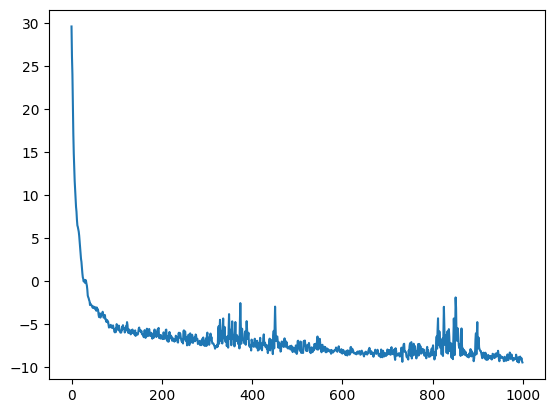

In [18]:
n_steps = 1000
losses = []
for cl_batch, cosmo_batch in tqdm(cl_dset_train.take(n_steps), total=n_steps):
    loss = model.grid_train_step(cl_batch, cosmo_batch)
    losses.append(loss)
    
plt.plot(losses)

In [19]:
preds = []
cosmos = []
for cl_batch, cosmo_batch in tqdm(cl_dset_test, total=grid_summs_test.shape[0]//batch_size):
    preds.append(model(cl_batch))
    cosmos.append(cosmo_batch)
    
preds = np.concatenate(preds, axis=0)
cosmos = np.concatenate(cosmos, axis=0)

# np.save("./predictions/mse_preds.npy", preds)
# np.save("./predictions/mse_cosmos.npy", preds)

30it [00:00, 140.34it/s]                        


In [20]:
grid_preds = model(grid_summs_test)
np.save("./predictions/like_grid_preds.npy", grid_preds)
np.save("./predictions/like_grid_cosmos.npy", grid_cosmos_test)

fidu_preds = model(fidu_summs)
np.save("./predictions/like_fidu_preds.npy", fidu_preds)